## 📋 Dictionnaire des variables — df_final

| Variable | Description | Unité |
|---|---|---|
| `dispo_alimentaire` | Disponibilité alimentaire par personne et par jour | kcal/personne/jour |
| `ease_business` | Facilité à faire des affaires (Banque Mondiale) | Score 0-100 |
| `pib_par_hab` | PIB par habitant | USD courants |
| `stab_politique` | Stabilité politique (WGI Banque Mondiale) | Score -2.5 à +2.5 |
| `population` | Population totale | Milliers d'habitants |
| `croissance` | Taux de croissance démographique 2013-2017 | % |
| `tx_urbanisation` | Taux d'urbanisation | % |
| `affordability` | Accessibilité financière à l'alimentation (100 - PUA%) | Score 0-100 |
| `prod_par_hab` | Production de volaille par habitant | tonnes / milliers d'hab → **kg/hab** |
| `import_par_hab` | Importations de volaille par habitant | tonnes / milliers d'hab → **kg/hab** |
| `tdi` | Trade Dependency Index (imports/dispo intérieure × 100) | % |

> ⚠️ Les unités de `prod_par_hab` et `import_par_hab` se simplifient : tonnes / milliers d'habitants = **kg/habitant**

In [1]:
import pandas as pd
from tools import sherlock, box, histo, heatmap_corr

In [2]:
df = pd.read_csv(r"..\data\processed\final.csv", sep=';')

In [3]:
sherlock(df)

131 lignes | 13 colonnes | 0 lignes doublons
--------------------------------------------------
                      Type  Manquants Manquants %  Uniques
pays                   str          0        0.0%      131
dispo_alimentaire  float64          0        0.0%       92
ease_business      float64          0        0.0%      131
pib_par_hab        float64          0        0.0%      131
stab_politique     float64          0        0.0%      131
population         float64          0        0.0%      131
croissance         float64          0        0.0%      131
tx_urbanisation    float64          0        0.0%      131
affordability      float64          0        0.0%      118
iso3                   str          0        0.0%      131
prod_par_hab       float64          0        0.0%      130
import_par_hab     float64          0        0.0%      114
tdi                float64          0        0.0%      110
--------------------------------------------------
Clé potentielle sur pays, e

In [4]:
df.describe()

,dispo_alimentaire,ease_business,pib_par_hab,stab_politique,population,croissance,tx_urbanisation,affordability,prod_par_hab,import_par_hab,tdi
count,131.000000,131.000000,131.000000,131.000000,1.310000e+02,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000
mean,69.763359,63.032039,14239.527812,-0.100980,5.185658e+04,5.538937,59.221008,66.274046,17.756200,6.880516,36.442518
std,56.036229,13.009273,20048.650004,0.839058,1.742295e+05,4.743911,20.799658,26.138570,17.776633,10.366308,42.069960
min,0.000000,32.351740,432.324026,-2.218410,1.108740e+02,-5.434483,15.963428,7.000000,0.000000,0.000000,0.000000
25%,21.000000,53.162910,1843.711244,-0.692480,4.144813e+03,2.187988,42.872589,43.400000,2.574627,0.163851,2.199904
50%,62.000000,63.574390,5955.297386,-0.142220,1.056945e+04,5.007410,61.129673,71.400000,12.094367,2.903089,20.000000
75%,103.500000,73.958800,16247.390388,0.646306,3.615668e+04,9.096571,74.430610,90.250000,27.066606,9.627984,70.176895
max,241.000000,87.022130,110193.213797,1.492485,1.421022e+06,16.742618,95.228824,99.700000,76.299320,63.134730,222.368421


In [5]:
df.head()

,pays,dispo_alimentaire,ease_business,pib_par_hab,stab_politique,population,croissance,tx_urbanisation,affordability,iso3,prod_par_hab,import_par_hab,tdi
0,Afrique du Sud,143.0,65.32778,6618.335083,-0.382832,57009.756,6.188887,63.331108,39.2,ZAF,29.240609,9.016001,24.268178
1,Albanie,85.0,66.83770,5006.360130,0.163830,2884.169,-0.675703,55.980276,75.7,ALB,4.507364,13.175372,80.851064
2,Algérie,22.0,46.22686,4554.667540,-0.929505,41389.189,8.518733,71.322791,81.2,DZA,6.644247,0.048322,0.722022
3,Allemagne,71.0,79.34962,45553.934150,0.702224,82658.409,1.828215,80.984254,97.3,DEU,18.316346,10.186501,48.418631
4,Angola,35.0,39.00774,2790.718869,-0.537214,29816.766,14.610305,65.085053,39.3,AGO,1.408603,9.290075,86.833856


### Detection des Outliers

In [6]:
df.nlargest(5, 'population')

,pays,dispo_alimentaire,ease_business,pib_par_hab,stab_politique,population,croissance,tx_urbanisation,affordability,iso3,prod_par_hab,import_par_hab,tdi
25,Chine,59.0,64.20096,8979.676527,-0.203288,1421021.791,2.093456,60.240269,70.8,CHN,12.833019,0.318081,2.488850
51,Inde,7.0,60.90760,1950.104683,-0.572111,1338676.785,4.515362,33.182133,40.8,IND,2.648137,0.000000,0.000000
129,Etats-Unis d'Amérique,219.0,83.59008,59635.098440,0.110129,325084.756,2.744691,80.401868,95.0,USA,67.410113,0.378363,0.673382
52,Indonésie,25.0,66.86799,3798.883262,-0.581615,264650.963,5.101424,54.454102,50.7,IDN,8.694471,0.003779,0.043048
92,Pakistan,20.0,53.01708,1519.234595,-2.218410,207906.209,8.702987,36.435155,41.4,PAK,6.161432,0.009620,0.156006


In [7]:
df.nsmallest(5, 'population')

,pays,dispo_alimentaire,ease_business,pib_par_hab,stab_politique,population,croissance,tx_urbanisation,affordability,iso3,prod_par_hab,import_par_hab,tdi
42,Grenade,192.0,53.30874,9751.426612,0.913473,110.874,2.499769,36.017330,80.6,GRD,9.019247,63.134730,87.500000
104,Sainte-Lucie,241.0,63.57439,11333.112382,0.866853,180.954,1.938450,21.783720,91.4,LCA,5.526266,55.262663,90.909091
105,Sao Tomé-et-Principe,33.0,44.67002,1555.794778,0.214501,207.089,7.810003,67.652000,51.1,STP,4.828842,9.657683,100.000000
56,Islande,104.0,78.99464,72976.372999,1.250357,334.393,2.202410,93.771898,99.4,ISL,29.904932,5.980986,20.000000
12,Belize,110.0,55.27374,6071.854518,0.027457,375.769,8.693288,43.421109,34.3,BLZ,53.224188,0.000000,0.000000


In [8]:
df.nlargest(5, 'pib_par_hab')

,pays,dispo_alimentaire,ease_business,pib_par_hab,stab_politique,population,croissance,tx_urbanisation,affordability,iso3,prod_par_hab,import_par_hab,tdi
70,Luxembourg,69.0,69.58844,110193.213797,1.271542,591.910,9.095768,92.096377,97.4,LUX,0.000000,18.583906,100.000000
111,Suisse,55.0,76.60784,82254.376927,1.164157,8455.804,4.278348,77.912627,98.7,CHE,10.761839,6.031360,38.345865
88,Norvège,66.0,82.65956,76131.838403,1.095694,5296.326,4.269572,81.969975,98.1,NOR,19.069823,0.377620,1.960784
56,Islande,104.0,78.99464,72976.372999,1.250357,334.393,2.202410,93.771898,99.4,ISL,29.904932,5.980986,20.000000
55,Irlande,100.0,80.10187,72161.404753,0.941803,4753.279,2.986877,62.903520,97.7,IRL,23.141920,20.827728,77.343750


In [9]:
df.nsmallest(5, 'pib_par_hab')

,pays,dispo_alimentaire,ease_business,pib_par_hab,stab_politique,population,croissance,tx_urbanisation,affordability,iso3,prod_par_hab,import_par_hab,tdi
101,Centrafricaine (la République),8.0,32.35174,432.324026,-1.826510,4596.023,3.329156,40.815144,13.1,CAF,1.523056,0.870318,36.363636
82,Mozambique,13.0,52.78803,470.938563,-1.065302,28649.018,12.082049,32.627441,15.6,MOZ,3.211279,0.837725,20.689655
72,Madagascar,14.0,46.38142,491.866849,-0.535016,25570.512,11.363739,29.671033,7.0,MDG,3.167711,0.000000,0.000000
74,Malawi,17.0,59.52076,495.769683,-0.313001,17670.196,11.559296,15.963428,16.0,MWI,7.357021,0.000000,0.000000
86,Niger,3.0,51.17303,521.804130,-1.041280,21602.382,16.742618,16.503699,13.9,NER,0.879533,0.138874,14.285714


In [10]:
df.nlargest(5, 'tdi')

,pays,dispo_alimentaire,ease_business,pib_par_hab,stab_politique,population,croissance,tx_urbanisation,affordability,iso3,prod_par_hab,import_par_hab,tdi
11,Belgique,44.0,72.18146,44035.323936,0.364760,11419.748,2.382453,86.673174,97.9,BEL,40.543802,29.597851,222.368421
40,Gambie,12.0,47.75707,642.522641,-0.196954,2213.889,12.740005,60.471713,57.0,GMB,0.903388,7.227101,200.000000
21,Cap-Vert,62.0,53.98064,3893.095714,0.720325,537.498,5.031773,69.199999,70.4,CPV,1.860472,22.325664,120.000000
81,Mongolie,9.0,67.40642,3645.967087,0.716039,3113.786,8.050376,67.926058,71.4,MNG,0.000000,3.211524,111.111111
79,Mauritanie,11.0,48.44839,1615.004013,-0.763787,4282.570,12.182757,54.197045,48.3,MRT,1.167523,5.604112,109.090909


### Analyse des distributions

In [11]:
liste_col = df.select_dtypes('number').columns

compteur = 1
for col in liste_col:
    histo(df, col, titre=f"Distribution pour {col} : {compteur}").show()
    compteur +=1

### Analyse des correlations

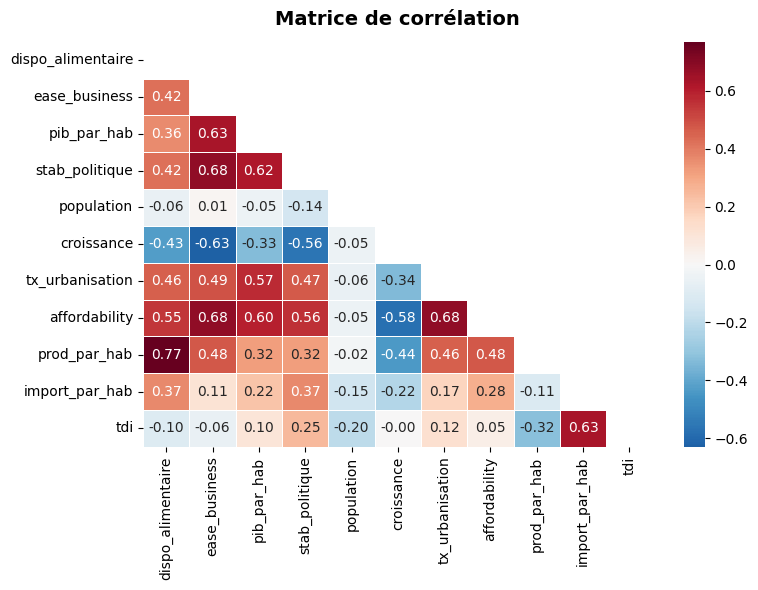

In [12]:
heatmap_corr(df)

## 🔍 Synthèse EDA — Conclusions pré-ACP

### Distribution des variables
- **Fortement skewées à droite** : `pib_par_hab`, `population`, `import_par_hab`, 
`tdi`, `prod_par_hab` — logique vu la nature des données
- **Distributions proches de la normale** : `stab_politique`, `croissance`, 
`tx_urbanisation` — variables qui discrimineront bien dans l'ACP
- **Bimodale** : `affordability` — deux groupes naturels (pays riches vs pauvres), 
variable discriminante à conserver malgré le doute initial

### Outliers
- Inde et Chine très extrêmes sur `population` → conservés (pertinence métier)
- Gambie, Cap-Vert sur `tdi` > 100 → imports supérieurs à la dispo intérieure, 
une partie des imports est réexportée
- Aucune erreur de saisie détectée → **131 pays conservés, ~90% pop mondiale**

### Corrélations notables
- `dispo_alimentaire` / `prod_par_hab` : **0.78** → logique, forte production = 
forte dispo locale
- `tdi` / `import_par_hab` : **0.62** → les deux mesurent la dépendance aux imports
- `croissance` corrélée négativement à `ease_business` (-0.63) et `stab_politique` 
(-0.56) → signal pays développés vs en développement
- Pas de corrélation > 0.90 → **aucune variable à exclure**

### Décisions pré-ACP
- Scaling obligatoire (échelles très hétérogènes)
- Toutes les variables conservées
- `prod_par_hab` et `import_par_hab` convertis en **kg/hab**